In [1]:
# =========================================================
# Project Title : Hacker News Post Analysis System
# Description   : Clean and analyze Hacker News data to find
#                 engagement patterns and best posting hours
# Group Members:  Shiza Ali(BSD-021) & Noor-ul-Ain(BSD-009)
# Submitted To: Ms.Noorhan Yasin
# =========================================================

In [3]:
pip install pandas  matplotlib datetime seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
#1.Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
sns.set(style="whitegrid")

In [30]:
                                                            #DATA CLEANING SECTION

In [5]:
# 2. Load Dataset
file_path = "hacker_news.csv"
df = pd.read_csv(file_path)
print("Original Dataset Shape:", df.shape)

Original Dataset Shape: (20100, 7)


In [5]:
# 3. Clean Column Names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [9]:
# 4. Handle Missing Values
# Remove rows with missing title or created_at
df.dropna(subset=["title", "created_at"], inplace=True)
# Replace missing numeric values with 0
df["num_comments"] = df["num_comments"].fillna(0)
df["num_points"] = df["num_points"].fillna(0)


In [8]:
# 5. Fix Data Types
df["num_comments"] = df["num_comments"].astype(int)
df["num_points"] = df["num_points"].astype(int)
# Convert date column to datetime
df["created_at"] = pd.to_datetime(df["created_at"])

In [6]:
#6. Clean Title Text
df["title"] = df["title"].str.strip().str.lower()
print("Cleaned Dataset Shape:", df.shape)

Cleaned Dataset Shape: (20100, 7)


In [13]:
                                                            # DATA ANALYSIS SECTION

In [10]:
# 7. Separate Post Types
ask_df = df[df["title"].str.startswith("ask hn")]
show_df = df[df["title"].str.startswith("show hn")]
other_df = df[~df.index.isin(ask_df.index) & ~df.index.isin(show_df.index)]
print("\nPost Counts:")
print("Ask HN:", len(ask_df))
print("Show HN:", len(show_df))
print("Other:", len(other_df))


Post Counts:
Ask HN: 1744
Show HN: 1162
Other: 17194


In [11]:
# 8. Average Comments
avg_ask_comments = ask_df["num_comments"].mean()
avg_show_comments = show_df["num_comments"].mean()
print("\nAverage Comments:")
print("Ask HN:", round(avg_ask_comments, 2))
print("Show HN:", round(avg_show_comments, 2))


Average Comments:
Ask HN: 14.04
Show HN: 10.32


In [14]:
# 9. Ask HN Comments by Hour
# Create a safe copy
ask_df = df[df["title"].str.startswith("ask hn")].copy()
# Extract hour
ask_df["hour"] = ask_df["created_at"].dt.hour
# Group by hour
hourly_avg = (
    ask_df
    .groupby("hour")["num_comments"]
    .mean()
    .reset_index()
    .sort_values("hour")
)
# Top 5 hours
top5_hours = hourly_avg.sort_values(
    "num_comments", ascending=False
).head(5)
print("\nTop 5 Best Hours to Post Ask HN:")
print(top5_hours)



Top 5 Best Hours to Post Ask HN:
    hour  num_comments
15    15     38.594828
2      2     23.810345
20    20     21.525000
16    16     16.796296
21    21     16.009174


In [19]:
                                                              #VISUALIZATION SECTION

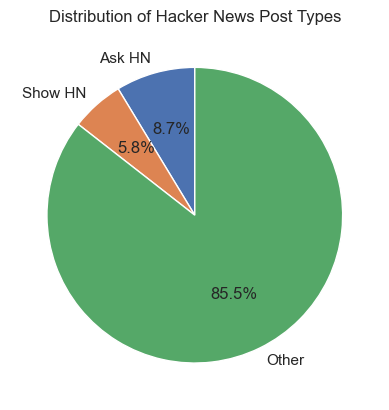

In [40]:
# Graph 1: Pie Chart – Post Type Distribution
plt.figure()
plt.pie(
    [len(ask_df), len(show_df), len(other_df)],
    labels=["Ask HN", "Show HN", "Other"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Distribution of Hacker News Post Types")
plt.show()

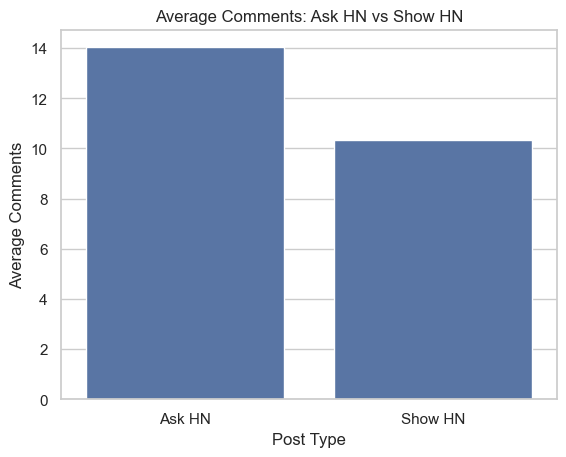

In [41]:
# Graph 2: Bar Chart – Avg Comments (Seaborn)
avg_comments_df = pd.DataFrame({
    "Post Type": ["Ask HN", "Show HN"],
    "Average Comments": [avg_ask_comments, avg_show_comments]})
plt.figure()
sns.barplot(
    data=avg_comments_df,
    x="Post Type",
    y="Average Comments"
)
plt.title("Average Comments: Ask HN vs Show HN")
plt.show()

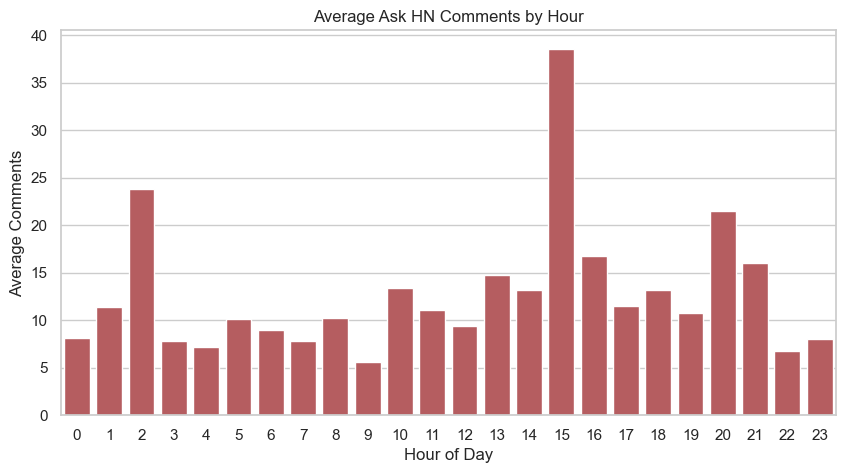

In [50]:
# Graph 3: Bar Chart–Avg Comments by Hour
plt.figure(figsize=(10, 5))
sns.barplot(
    data=hourly_avg,
    x="hour",
    y="num_comments",
    color = "r"
)
plt.xlabel("Hour of Day")
plt.ylabel("Average Comments")
plt.title("Average Ask HN Comments by Hour")
plt.show()

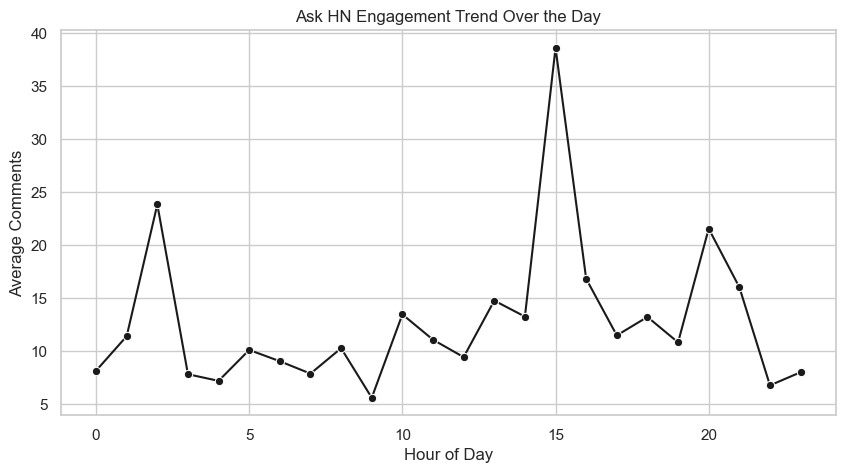

In [28]:
# Graph 4: Line Chart – Engagement Trend
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=hourly_avg,
    x="hour",
    y="num_comments",
    marker="o",
    color = "k" 
)
plt.xlabel("Hour of Day")
plt.ylabel("Average Comments")
plt.title("Ask HN Engagement Trend Over the Day")
plt.show()

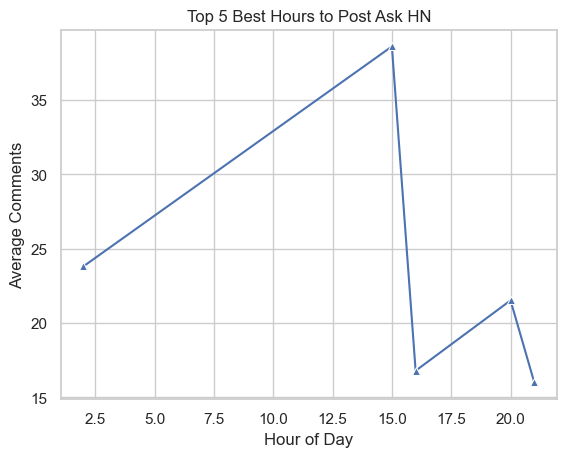

In [32]:
# Graph 5: Line Chart–Top 5 Hours
plt.figure()
sns.lineplot(
    data=top5_hours,
    x="hour",
    y="num_comments",
    marker="^"
)
plt.xlabel("Hour of Day")
plt.ylabel("Average Comments")
plt.title("Top 5 Best Hours to Post Ask HN")
plt.show()

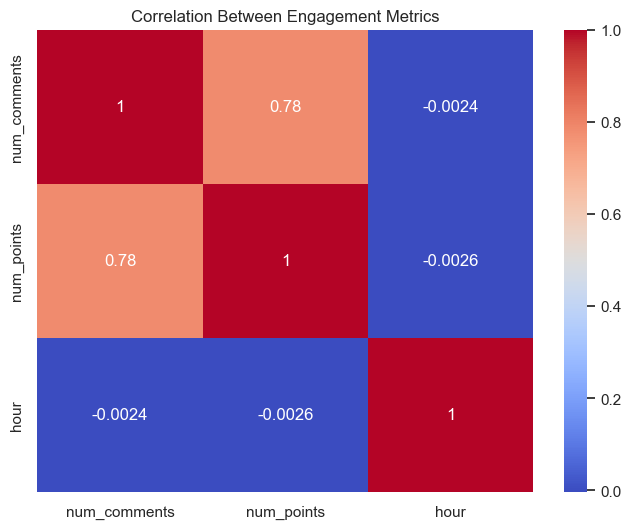

In [37]:
# Graph 6:Relationship between comments,points & posting-hours
corr_df = df[["num_comments", "num_points"]].copy()
corr_df["hour"] = df["created_at"].dt.hour

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap="coolwarm")
plt.title("Correlation Between Engagement Metrics")
plt.show()

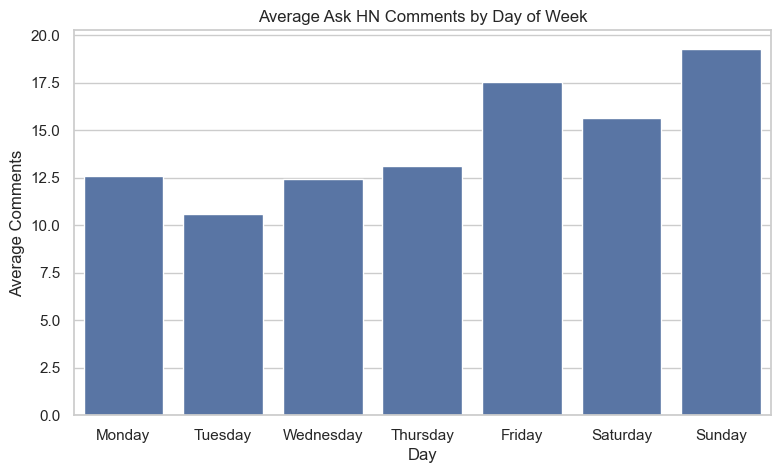

In [39]:
# Group 7: Days-of-Week Analysis
ask_df["day"] = ask_df["created_at"].dt.day_name()
day_avg = ask_df.groupby("day")["num_comments"].mean().reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
)
plt.figure(figsize=(9,5))
sns.barplot(x=day_avg.index, y=day_avg.values)
plt.title("Average Ask HN Comments by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Comments")
plt.show()

In [25]:
                                                                      #CONCLUSION

In [4]:
print("\nConclusion:")
print("After cleaning the dataset, Ask HN posts were found to")
print("receive significantly higher engagement than Show HN posts.")
print("The best time to post Ask HN questions is during afternoon")
print("hours, particularly around 3 PM.")
print("The best day to post Ask HN news is Sunday")
print("Top 5 Best Hours to Post Ask HN are: 2 , 15 , 16 , 20 , 21")



Conclusion:
After cleaning the dataset, Ask HN posts were found to
receive significantly higher engagement than Show HN posts.
The best time to post Ask HN questions is during afternoon
hours, particularly around 3 PM.
The best day to post Ask HN news is Sunday
Top 5 Best Hours to Post Ask HN are: 2 , 15 , 16 , 20 , 21


In [52]:
df.to_csv("Hacker.csv")